In [204]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

In [205]:
df = pd.read_csv('Breast_Cancer.csv')

In [206]:
df.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 non-null   int64 
 15  Stat

In [208]:
df.duplicated().sum()

1

In [209]:
df.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


In [210]:
df.columns = df.columns.str.strip().str.lower()

In [211]:
df.columns=df.columns.str.replace(' ','_')

In [212]:
df.columns

Index(['age', 'race', 'marital_status', 't_stage', 'n_stage', '6th_stage',
       'differentiate', 'grade', 'a_stage', 'tumor_size', 'estrogen_status',
       'progesterone_status', 'regional_node_examined',
       'reginol_node_positive', 'survival_months', 'status'],
      dtype='object')

In [213]:
df.drop_duplicates(inplace=True)

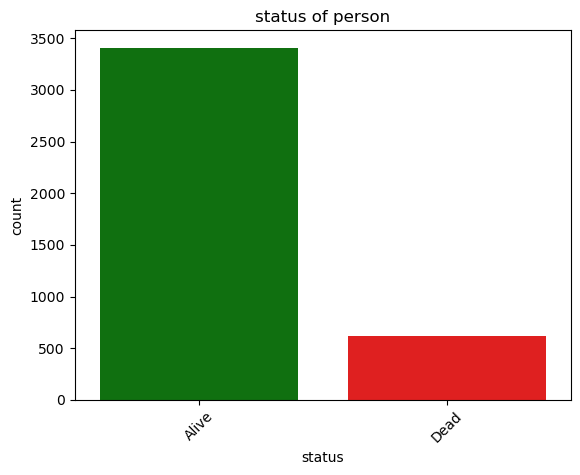

In [214]:
sns.countplot(x = 'status',data=df,palette=['g','r'])
plt.title('status of person')
plt.xticks(rotation=45)
plt.show()

In [215]:
df['status'].value_counts()

status
Alive    3407
Dead      616
Name: count, dtype: int64

In [216]:
la = LabelEncoder()

In [217]:
obj = df.select_dtypes(include='object')
non_obj = df.select_dtypes(exclude='object')

In [218]:
for i in range(0,obj.shape[1]):
    obj.iloc[:,i] = la.fit_transform(obj.iloc[:,i])

In [219]:
obj = obj.astype('int')

In [220]:
scaler = StandardScaler()

In [221]:
non_obj

,age,tumor_size,regional_node_examined,reginol_node_positive,survival_months
0,68,4,24,1,60
1,50,35,14,5,62
2,58,63,14,7,75
3,58,18,2,1,84
4,47,41,3,1,50
...,...,...,...,...,...
4019,62,9,1,1,49
4020,56,46,14,8,69
4021,68,22,11,3,69
4022,58,44,11,1,72


In [222]:
cols_to_scale = ['age', 'reginol_node_positive', 'regional_node_examined', 'survival_months', 'tumor_size']
non_obj[cols_to_scale] = scaler.fit_transform(non_obj[cols_to_scale])
non_obj.head()

,age,tumor_size,regional_node_examined,reginol_node_positive,survival_months
0,1.565507,-1.253728,1.190429,-0.618278,-0.493093
1,-0.442973,0.214171,-0.044256,0.164641,-0.405833
2,0.449685,1.540015,-0.044256,0.556100,0.161353
3,0.449685,-0.590806,-1.525877,-0.618278,0.554020
4,-0.777719,0.498280,-1.402409,-0.618278,-0.929390


In [223]:
df = pd.concat([non_obj,obj],axis=1)

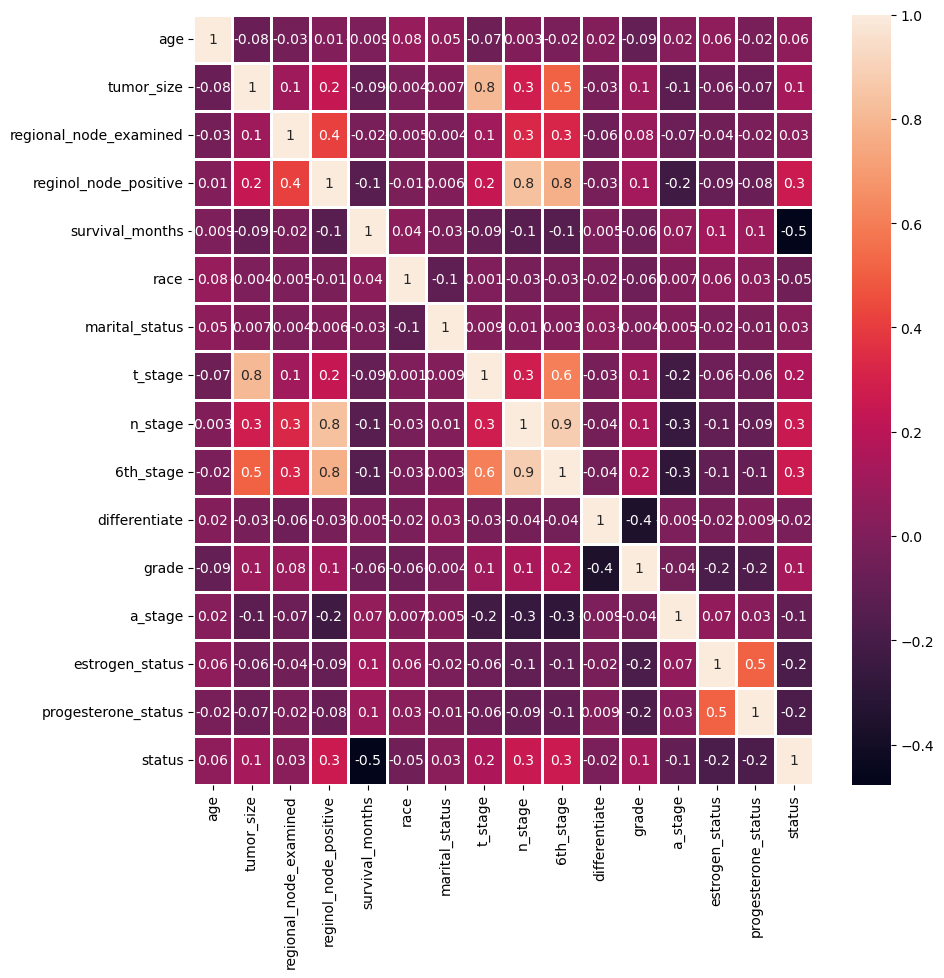

In [224]:
plt.figure(figsize=[10,10])
sns.heatmap(df.corr(),annot=True,linewidths=0.8,fmt='.1g')
plt.show()

In [225]:
x = df.drop('status',axis=1)

In [226]:
y = df['status']

In [227]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle =True)

print('X_train shape is ' , x_train.shape)
print('X_test shape is ' , x_test.shape)
print('y_train shape is ' , y_train.shape)
print('y_test shape is ' , y_test.shape)

X_train shape is  (3218, 15)
X_test shape is  (805, 15)
y_train shape is  (3218,)
y_test shape is  (805,)


In [228]:
model1 = RandomForestClassifier(n_estimators=100,class_weight='balanced', random_state=42)

In [229]:
model2 = GradientBoostingClassifier(learning_rate=0.1,n_estimators=100,subsample=1.0,random_state=42)

In [230]:
model3 = LogisticRegression()

In [231]:
model4 = SVC()

In [232]:
model5 = DecisionTreeClassifier()

In [233]:
model6 = KNeighborsClassifier()

In [234]:
def pre(model):
    model.fit(x_train,y_train)
    pred = model.predict(x_test)
    acc = accuracy_score(pred,y_test)
    clr = classification_report(pred,y_test)
    print('accuracy is: ', acc)
    print('classification_reportis: ', clr)

In [235]:
pre(model1)

accuracy is:  0.9105590062111801
classification_reportis:                precision    recall  f1-score   support

           0       0.98      0.92      0.95       722
           1       0.54      0.83      0.66        83

    accuracy                           0.91       805
   macro avg       0.76      0.88      0.80       805
weighted avg       0.93      0.91      0.92       805



In [236]:
pre(model2)

accuracy is:  0.9105590062111801
classification_reportis:                precision    recall  f1-score   support

           0       0.98      0.92      0.95       720
           1       0.55      0.82      0.66        85

    accuracy                           0.91       805
   macro avg       0.76      0.87      0.80       805
weighted avg       0.93      0.91      0.92       805



In [237]:
pre(model3)

accuracy is:  0.9006211180124224
classification_reportis:                precision    recall  f1-score   support

           0       0.98      0.91      0.94       734
           1       0.46      0.83      0.60        71

    accuracy                           0.90       805
   macro avg       0.72      0.87      0.77       805
weighted avg       0.94      0.90      0.91       805



In [238]:
pre(model4)

accuracy is:  0.893167701863354
classification_reportis:                precision    recall  f1-score   support

           0       0.99      0.90      0.94       744
           1       0.40      0.84      0.54        61

    accuracy                           0.89       805
   macro avg       0.69      0.87      0.74       805
weighted avg       0.94      0.89      0.91       805



In [239]:
pre(model5)

accuracy is:  0.8434782608695652
classification_reportis:                precision    recall  f1-score   support

           0       0.91      0.90      0.91       684
           1       0.48      0.50      0.49       121

    accuracy                           0.84       805
   macro avg       0.70      0.70      0.70       805
weighted avg       0.85      0.84      0.85       805



In [240]:
pre(model6)

accuracy is:  0.8807453416149068
classification_reportis:                precision    recall  f1-score   support

           0       0.97      0.90      0.93       734
           1       0.40      0.72      0.52        71

    accuracy                           0.88       805
   macro avg       0.69      0.81      0.72       805
weighted avg       0.92      0.88      0.90       805



In [241]:
sm = SMOTE(random_state=42)

In [242]:
x_train_res , y_train_res = sm.fit_resample(x_train,y_train)

In [243]:
mod = GradientBoostingClassifier(random_state=42)

In [244]:
mod.fit(x_train_res,y_train_res)

GradientBoostingClassifier(random_state=42)

In [245]:
pred = mod.predict(x_test)

In [246]:
acc = accuracy_score(y_test,pred)
clr = classification_report(y_test,pred)
print('accuracy is: ', acc)
print('classification_reportis: ', clr)

accuracy is:  0.8956521739130435
classification_reportis:                precision    recall  f1-score   support

           0       0.94      0.93      0.94       678
           1       0.66      0.70      0.68       127

    accuracy                           0.90       805
   macro avg       0.80      0.82      0.81       805
weighted avg       0.90      0.90      0.90       805



In [247]:
param_grid = {'n_estimators': [100, 200],
'learning_rate': [0.01, 0.1, 0.2],
'max_depth': [3, 4, 5],
'subsample': [0.8, 1.0]
}

In [248]:
grid_search = GridSearchCV(estimator=mod,param_grid=param_grid,cv=5,scoring='f1',n_jobs=-1)

In [249]:
grid_search.fit(x_train_res,y_train_res)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 4, 5], 'n_estimators': [100, 200],
                         'subsample': [0.8, 1.0]},
             scoring='f1')

In [250]:
print('best param is: ', grid_search.best_params_)
print('best score is: ', grid_search.best_score_)

best param is:  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
best score is:  0.9067759104583096


In [253]:
best_model = grid_search.best_estimator_

In [254]:
final_pred = best_model.predict(x_test)

In [255]:
print(classification_report(y_test,final_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       678
           1       0.70      0.60      0.64       127

    accuracy                           0.90       805
   macro avg       0.81      0.77      0.79       805
weighted avg       0.89      0.90      0.89       805



In [256]:
accuracy_score(y_test,final_pred)

0.8956521739130435

In [260]:
df

,age,tumor_size,regional_node_examined,reginol_node_positive,survival_months,race,marital_status,t_stage,n_stage,6th_stage,differentiate,grade,a_stage,estrogen_status,progesterone_status,status
0,1.565507,-1.253728,1.190429,-0.618278,-0.493093,2,1,0,0,0,1,3,1,1,1,0
1,-0.442973,0.214171,-0.044256,0.164641,-0.405833,2,1,1,1,2,0,2,1,1,1,0
2,0.449685,1.540015,-0.044256,0.556100,0.161353,2,0,2,2,4,0,2,1,1,1,0
3,0.449685,-0.590806,-1.525877,-0.618278,0.554020,2,1,0,0,0,1,3,1,1,1,0
4,-0.777719,0.498280,-1.402409,-0.618278,-0.929390,2,1,1,0,1,1,3,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4019,0.896014,-1.016970,-1.649346,-0.618278,-0.973020,1,1,0,0,0,0,2,1,1,1,0
4020,0.226520,0.735038,-0.044256,0.751829,-0.100425,2,0,1,1,2,0,2,1,1,1,0
4021,1.565507,-0.401400,-0.414661,-0.226819,-0.100425,2,1,1,0,1,0,2,1,1,0,0
4022,0.449685,0.640335,-0.414661,-0.618278,0.030464,0,0,1,0,1,0,2,1,1,1,0


In [263]:
import pickle

# تأكد إن ده الموديل اللي عملتله fit مش النتائج
# لو اسم المتغير عندك مختلف، اتأكد إنك بتسيف الـ Estimator
with open('breast_cancer_model.pkl', 'wb') as f:
    pickle.dump(best_model, f) 

# وسيف الـ Scaler برضه عشان نضمن إنه Object مش Array
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ كدة أنت سيففت 'المخ' (Model) و 'المكينة' (Scaler) صح كـ Objects")

✅ كدة أنت سيففت 'المخ' (Model) و 'المكينة' (Scaler) صح كـ Objects
